In [1]:
import os
from pathlib import Path
import pandas as pd
import networkx as nx

# Find project root and data directory
project_root = Path.cwd().resolve()
for folder in [project_root, *project_root.parents]:
    if (folder / "data" / "nodes_complete.csv").exists():
        project_root = folder
        data_dir = folder / "data"
        break
else:
    raise FileNotFoundError("Could not locate the data directory containing nodes_complete.csv.")

# Load data
df_nodes = pd.read_csv(data_dir / "nodes_complete.csv")
df_edges = pd.read_csv(data_dir / "edges_data.csv")
df_tanks = pd.read_excel(data_dir / "data set 32 tanks.xlsx")

# Merge tank attributes onto nodes
df_tanks_clean = df_tanks.rename(
    columns={"NAME OF SCHEME": "tank_name"})
df_full = df_nodes.merge(df_tanks_clean, on="tank_name", how="left")

print(f"Nodes: {len(df_full)}, Edges: {len(df_edges)}")
print(df_full.columns.tolist())


Nodes: 32, Edges: 32
['tank_name', 'elevation_m', 'latitude', 'longitude', 'tank_area_sqkm', 'catchment_area_km2', 'num_catchment_basins', 'capacity_acre_feet', 'depth_m', 'spill_level_mls', 'perimeter_km', 'catchment_area_original', 'DISTRICT NO', 'GK _ NO', 'NATURE', 'STATUS', 'SUB _ NO', 'D_S_ AREA', 'G_N_AREA', 'COMMAND AREA', 'WATER HT (Ft)', 'ANICUT NATURE', 'TANK NATURE', 'DAM LENGTH (Ft)', 'MAX_ DAM HIGHT (Ft.)', 'TANK COND', 'MAX_ WATER HT (Ft)', 'NO _ OF FARMERS', 'REPAIRS 10 Y', 'IRRI- CO-ORD', 'AE _ REGION', 'HY _ ZONE', 'RIVER BASIN NO', 'CASCADE', 'WSA (ACRES)', 'G_ CATCH (Sq. Ml)', 'N _ CATCH', 'SOIL TYPE', 'TANK CAPACITY', 'REMARKS']


In [2]:
G = nx.DiGraph()

# Add nodes with attributes
for _, row in df_full.iterrows():
    G.add_node(row["tank_name"],
        elevation=row["elevation_m"],
        lat=row["latitude"],
        lon=row["longitude"],
        catchment=row["catchment_area_km2"],
        basins=row["num_catchment_basins"],
        command_area=row.get("COMMAND AREA", 0),
        farmers=row.get("NO _ OF FARMERS", 0),
        tank_cond=row.get("TANK COND", 2)
    )

# Add edges with attributes
for _, row in df_edges.iterrows():
    G.add_edge(row["source_tank"], row["target_tank"],
        elev_diff=row["elev_diff_m"],
        path_len=row["stream_path_length_m"],
        slope=row["slope_m/m"]
    )

print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print("Is DAG (no cycles):", nx.is_directed_acyclic_graph(G))

Graph: 32 nodes, 32 edges
Is DAG (no cycles): True


In [3]:
# 1. Downstream reach — how many tanks does each tank feed?
downstream_reach = {}
for node in G.nodes():
    descendants = nx.descendants(G, node)
    downstream_reach[node] = len(descendants)

# 2. Betweenness centrality — is it a bottleneck?
betweenness = nx.betweenness_centrality(G, normalized=True)

# 3. PageRank — how much does upstream importance flow through it?
pagerank = nx.pagerank(G, alpha=0.85)

# 4. In/Out degree — how many direct connections?
in_deg  = dict(G.in_degree())
out_deg = dict(G.out_degree())

# Build ranking DataFrame
df_rank = pd.DataFrame({
    "tank": list(G.nodes()),
    "downstream_reach": [downstream_reach[n] for n in G.nodes()],
    "betweenness": [betweenness[n] for n in G.nodes()],
    "pagerank": [pagerank[n] for n in G.nodes()],
    "in_degree": [in_deg[n] for n in G.nodes()],
    "out_degree": [out_deg[n] for n in G.nodes()],
})

# Composite importance score (normalise + sum)
from sklearn.preprocessing import MinMaxScaler
cols = ["downstream_reach","betweenness","pagerank"]
scaler = MinMaxScaler()
df_rank[[c+"_norm" for c in cols]] = scaler.fit_transform(df_rank[cols])
df_rank["importance_score"] = df_rank[[c+"_norm" for c in cols]].mean(axis=1)
df_rank = df_rank.sort_values("importance_score", ascending=False)
print(df_rank[["tank","downstream_reach","importance_score"]].head(10))

                         tank  downstream_reach  importance_score
13          Periyakulama Wewa                 4          0.620595
17           Manakkulama Wewa                 3          0.526593
2                Pansala Wewa                 6          0.460073
5             Ulankulama Wewa                 5          0.459195
22          Wannanmaduwa Wewa                 2          0.448146
9   Pahala Amanakkattuwa Wewa                 3          0.346355
30           Nachchaduwa Wewa                 0          0.333333
1           Settikulama  Wewa                 7          0.333333
0      Tawalanhalmillewa Wewa                 7          0.333333
16         Mahakanumulla Wewa                 2          0.321141


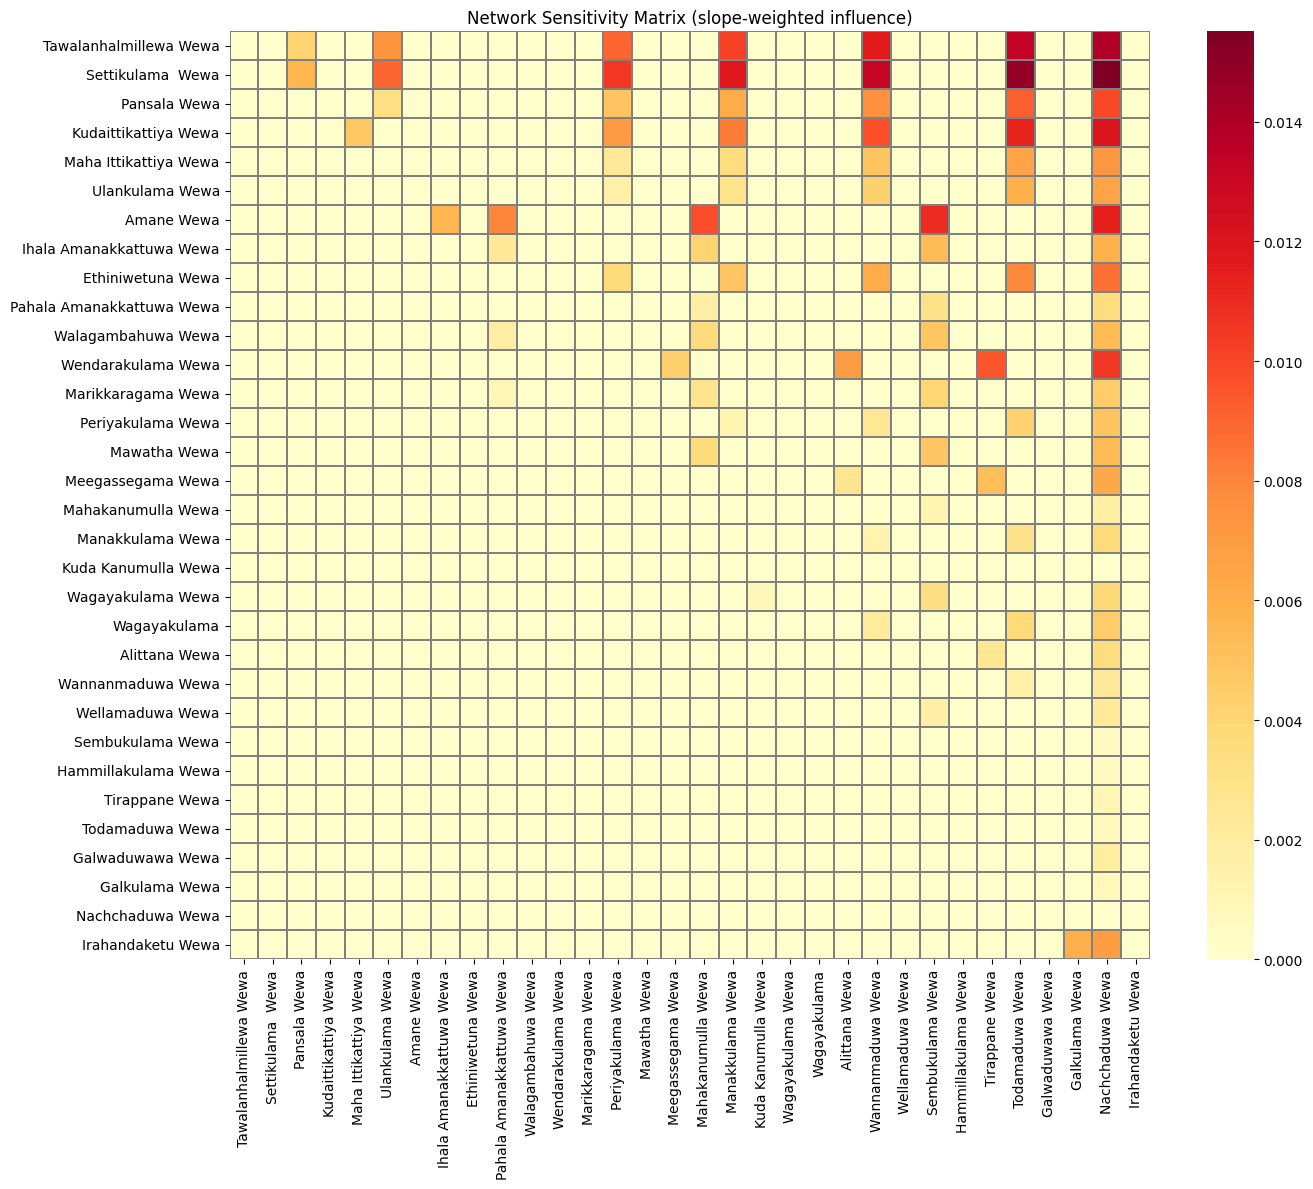

In [4]:
tanks = list(G.nodes())
n = len(tanks)
import numpy as np

sensitivity = np.zeros((n, n))

for i, src in enumerate(tanks):
    for j, tgt in enumerate(tanks):
        if src == tgt:
            continue
        if nx.has_path(G, src, tgt):
            # Weight by sum of slope along path
            paths = list(nx.all_simple_paths(G, src, tgt, cutoff=10))
            if paths:
                path = paths[0]
                slope_sum = sum(
                    G[path[k]][path[k+1]].get("slope", 0)
                    for k in range(len(path)-1)
                )
                sensitivity[i][j] = slope_sum

df_sensitivity = pd.DataFrame(
    sensitivity, index=tanks, columns=tanks)

# Plot heatmap
import seaborn as sns
import matplotlib.pyplot as plt

# Create output folder if it doesn't exist
output_dir = project_root / "outputs"
output_dir.mkdir(exist_ok=True)

plt.figure(figsize=(14, 12))
sns.heatmap(df_sensitivity, cmap="YlOrRd",
    linewidths=0.3, linecolor="gray",
    xticklabels=True, yticklabels=True)
plt.title("Network Sensitivity Matrix (slope-weighted influence)")
plt.tight_layout()
plt.savefig(output_dir / "sensitivity_matrix.png", dpi=150)
plt.show()


In [5]:
from pyvis.network import Network

net = Network(height="750px", width="100%",
              directed=True, bgcolor="#f9f9f7")

# Score → node size mapping
score_map = df_rank.set_index("tank")["importance_score"]

for node in G.nodes():
    score = score_map.get(node, 0)
    size = 10 + score * 40
    color = "#E24B4A" if score > 0.6 else ("#EF9F27" if score > 0.3 else "#1D9E75")
    net.add_node(node, label=node, size=size,
                 color=color, title=f"Score: {score:.3f}")

for src, tgt, data in G.edges(data=True):
    slope = data.get("slope", 0)
    net.add_edge(src, tgt,
        width=slope*1000,
        title=f"slope={slope:.4f}",
        color="#185FA5")

net.set_options("""
{
  "physics": {"enabled": true,
    "hierarchicalRepulsion": {"nodeDistance": 150}},
  "layout": {"hierarchical": {"enabled": true,
    "direction": "UD", "sortMethod": "directed"}}
}
""")
net.save_graph(str(output_dir / "cascade_influence_map.html"))
print(f"Saved! Open {output_dir / 'cascade_influence_map.html'} in your browser.")

Saved! Open C:\Users\dinit\OneDrive\Desktop\Research\code\cascade_gnn\outputs\cascade_influence_map.html in your browser.


In [6]:
df_export = df_rank[[
    "tank","importance_score","downstream_reach",
    "betweenness","pagerank","in_degree","out_degree"
]].copy()
df_export["rank"] = range(1, len(df_export)+1)
df_export = df_export.set_index("rank")

# Style with colour scale
styled = df_export.style.background_gradient(
    subset=["importance_score"], cmap="RdYlGn"
).format({
    "importance_score": "{:.3f}",
    "betweenness": "{:.4f}",
    "pagerank": "{:.4f}"
})

# Display in notebook
display(styled)

# Save as CSV
df_export.to_csv(output_dir / "critical_tank_ranking.csv")
print(f"Saved critical_tank_ranking.csv to {output_dir}")

,tank,importance_score,downstream_reach,betweenness,pagerank,in_degree,out_degree
rank,,,,,,,
1,Periyakulama Wewa,0.621,4,0.0301,0.0637,3,1
2,Manakkulama Wewa,0.527,3,0.0258,0.0644,1,1
3,Pansala Wewa,0.460,6,0.0129,0.0276,2,1
4,Ulankulama Wewa,0.459,5,0.0161,0.0337,1,1
5,Wannanmaduwa Wewa,0.448,2,0.0215,0.0737,2,1
6,Pahala Amanakkattuwa Wewa,0.346,3,0.0129,0.0438,3,1
7,Nachchaduwa Wewa,0.333,0,0.0000,0.1944,7,0
8,Settikulama Wewa,0.333,7,0.0000,0.0102,0,1
9,Tawalanhalmillewa Wewa,0.333,7,0.0000,0.0102,0,1


Saved critical_tank_ranking.csv to C:\Users\dinit\OneDrive\Desktop\Research\code\cascade_gnn\outputs


In [7]:
# Save everything Phase 2 needs
import pickle

models_dir = project_root  / "models"
models_dir.mkdir(exist_ok=True)

with open(models_dir / "phase1_outputs.pkl", "wb") as f:
    pickle.dump({
        "G": G,
        "df_full": df_full,
        "df_edges": df_edges,
        "df_rank": df_rank,
        "node_list": list(G.nodes()),
        "node_idx": {n: i for i, n in enumerate(G.nodes())}
    }, f)

print(f"Phase 1 outputs saved to {models_dir / 'phase1_outputs.pkl'}")


Phase 1 outputs saved to C:\Users\dinit\OneDrive\Desktop\Research\code\cascade_gnn\models\phase1_outputs.pkl
